# **Problem Statement**


---

#### **Business Context**  
Understanding customer personality and behavior is pivotal for businesses to enhance customer satisfaction and increase revenue. Segmentation based on a customer's personality, demographics, and purchasing behavior allows companies to create tailored marketing campaigns, improve customer retention, and optimize product offerings.  

A leading retail company with a rapidly growing customer base seeks to gain deeper insights into their customers' profiles. The company recognizes that understanding customer personalities, lifestyles, and purchasing habits can unlock significant opportunities for personalizing marketing strategies and creating loyalty programs. These insights can help address critical business challenges, such as improving the effectiveness of marketing campaigns, identifying high-value customer groups, and fostering long-term relationships with customers.  

With the competition intensifying in the retail space, moving away from generic strategies to more targeted and personalized approaches is essential for sustaining a competitive edge.  

---

#### **Objective**  
In an effort to optimize marketing efficiency and enhance customer experience, the company has embarked on a mission to identify distinct customer segments. By understanding the characteristics, preferences, and behaviors of each group, the company aims to:  
1. Develop personalized marketing campaigns to increase conversion rates.  
2. Create effective retention strategies for high-value customers.  
3. Optimize resource allocation, such as inventory management, pricing strategies, and store layouts.  

As a data scientist tasked with this project, your responsibility is to analyze the given customer data, apply machine learning techniques to segment the customer base, and provide actionable insights into the characteristics of each segment.  

---

#### **Data Dictionary**  
The dataset includes historical data on customer demographics, personality traits, and purchasing behaviors. Key attributes are:  

1. **Customer Information**  
   - **ID:** Unique identifier for each customer.  
   - **Year_Birth:** Customer's year of birth.  
   - **Education:** Education level of the customer.  
   - **Marital_Status:** Marital status of the customer.  
   - **Income:** Yearly household income (in dollars).  
   - **Kidhome:** Number of children in the household.  
   - **Teenhome:** Number of teenagers in the household.  
   - **Dt_Customer:** Date when the customer enrolled with the company.  
   - **Recency:** Number of days since the customer’s last purchase.  
   - **Complain:** Whether the customer complained in the last 2 years (1 for yes, 0 for no).  

2. **Spending Information (Last 2 Years)**  
   - **MntWines:** Amount spent on wine.  
   - **MntFruits:** Amount spent on fruits.  
   - **MntMeatProducts:** Amount spent on meat.  
   - **MntFishProducts:** Amount spent on fish.  
   - **MntSweetProducts:** Amount spent on sweets.  
   - **MntGoldProds:** Amount spent on gold products.  

3. **Purchase and Campaign Interaction**  
   - **NumDealsPurchases:** Number of purchases made using a discount.  
   - **AcceptedCmp1:** Response to the 1st campaign (1 for yes, 0 for no).  
   - **AcceptedCmp2:** Response to the 2nd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp3:** Response to the 3rd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp4:** Response to the 4th campaign (1 for yes, 0 for no).  
   - **AcceptedCmp5:** Response to the 5th campaign (1 for yes, 0 for no).  
   - **Response:** Response to the last campaign (1 for yes, 0 for no).  

4. **Shopping Behavior**  
   - **NumWebPurchases:** Number of purchases made through the company’s website.  
   - **NumCatalogPurchases:** Number of purchases made using catalogs.  
   - **NumStorePurchases:** Number of purchases made directly in stores.  
   - **NumWebVisitsMonth:** Number of visits to the company’s website in the last month.  

# **Let's start coding!**

## **Importing necessary libraries**

In [85]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

## **Loading the data**

In [86]:
# uncomment and run the following line if using Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [87]:
# loading data into a pandas dataframe
data = pd.read_csv("/content/drive/MyDrive/MIT IDSS/misc/CSVs/Customer_Personality_Segmentation.csv", sep="\t")

## **Data Overview**

#### **Question 1**: What are the data types of all the columns?

In [88]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

##### **Observations:
All columns with the exception of Education, Marital_Status, Dt_customer contain numerical data. To note: the other data columns are in integer type numerical data with the exception of Income which is in float type data.

**

#### **Question 2:** Check the statistical summary of the data. What is the average household income?

In [89]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


##### **Observations: After implementing the .describe() method for a statistical summary of the data, it is observed that the average/mean of the Income  column is $52,247.25**

#### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method

In [90]:
data.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


##### **Observations:** After applying the methods **.isnull()** and **.sum()**, each data point with missing values is totaled by column. This shows that **Income feature has 24  missing data points** and is the only column with missing data.


Income has 24 missing data points. The total number of rows is 2,240 which indicates that just about 1% of the data for Income is missing. A reasonable method to treat missing data in this case would be to input the **mean** of the Income column to the missing values. There is sufficient data to draw a good estimate of the true values and a low enough percentage of missing data that the new distribution won’t be skewed or misrepresented after data treatment. The data will still be closely represented in this way.


In [91]:
data['Income'].mean()

np.float64(52247.25135379061)

In [92]:
data['Income'] = data['Income'].fillna(data['Income'].mean())

In [93]:
data['Income'].isnull().sum()

np.int64(0)

Fianlly we check we have assigned the mean to the missing Income data by totaling the new total of NaN values.

#### **Question 4**: Are there any duplicates in the data?

In [94]:
data.duplicated().sum()

np.int64(0)

##### **Observations:**  After using the **duplicated()** and **sum()** methods, the total rows of duplicate data is summed. In this case each row seems to represent an individual data point.  

## **Exploratory Data Analysis**

### Univariate Analysis

#### **Question 5:** Explore all the variables and provide observations on their distributions. (histograms and boxplots)

In [95]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


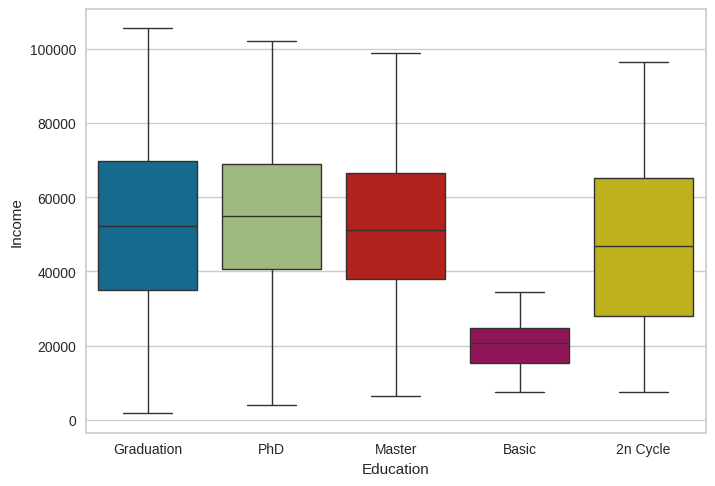

In [96]:
sns.boxplot(data=data, x='Education', y='Income', showfliers=False, hue='Education')
plt.ylabel('Income')
plt.show()

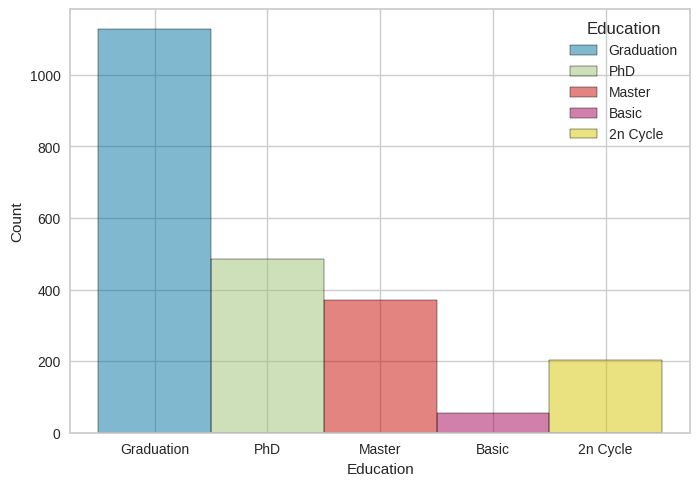

In [97]:
sns.histplot(data=data, x='Education', hue='Education')
plt.show()

##### **Observations:** The income level of customers is displayed against their education level in boxplots. The majority of overvations fall between the \$30,000 and \$70,000 with the exception of Basic which the majority of customers fall in between the \$10,000 and \$25,000.

The majority of customers are at a Graduation level accounting for almost half of the observed population.

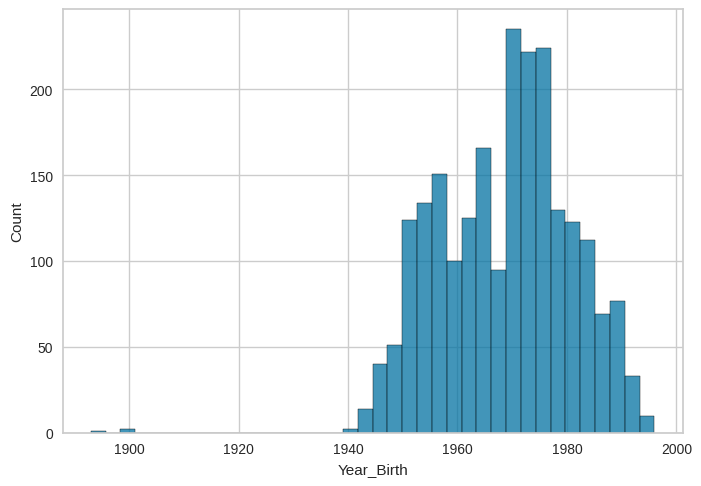

In [98]:
sns.histplot(data=data, x='Year_Birth')
plt.show()

**Observations:** There are outliers in the Year_Birth feature of the data. Possible cause is data entered incorrectly.

The majority of customers' birth year fall between 1950 and 1990 signaling a wide range of age in adults as customers.

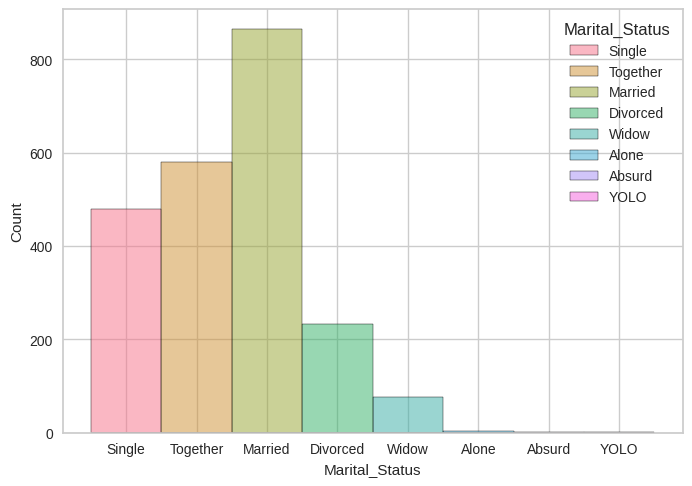

In [99]:
sns.histplot(data=data, x='Marital_Status', hue='Marital_Status')
plt.show()

In [100]:
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], format = "%d-%m-%Y")

**Obervations:** The majority of the cusotmer base identified as Single, Together or Married. Some Marital_Status categories may have been entered incorrectly; could be further treated. e.g. Alone may count as Single.

In [101]:
num_data = data.drop(columns = ['Education', 'Marital_Status', 'Dt_Customer'], inplace = False)

ID
Skew : 0.04


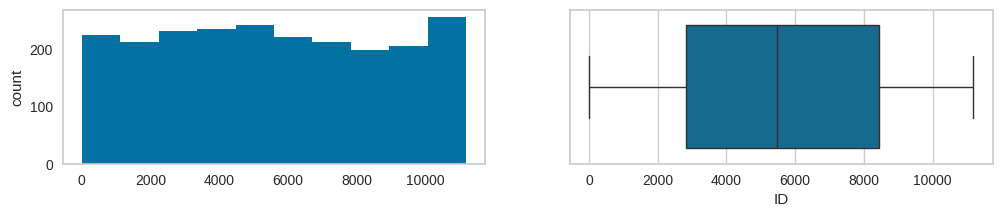

Year_Birth
Skew : -0.35


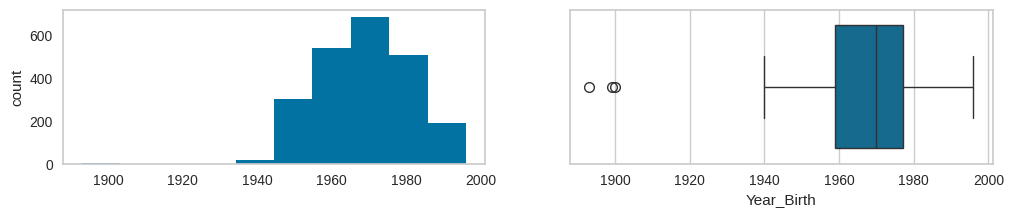

Income
Skew : 6.8


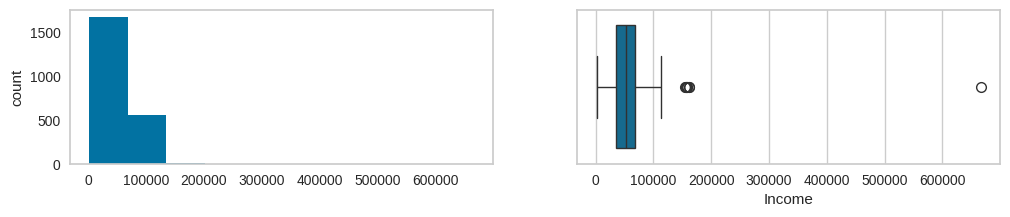

Kidhome
Skew : 0.64


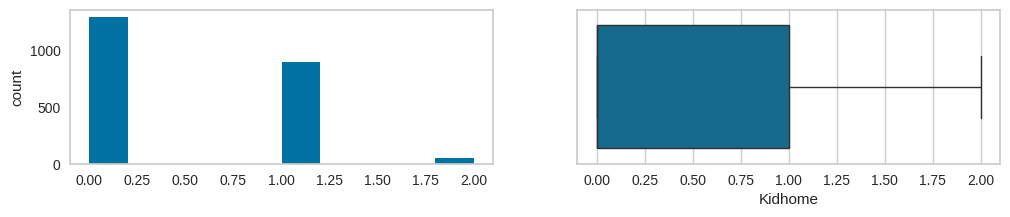

Teenhome
Skew : 0.41


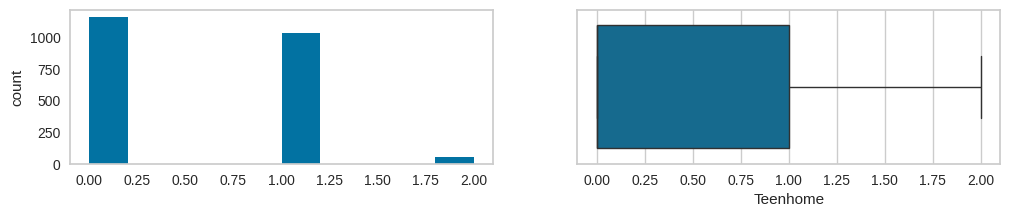

Recency
Skew : -0.0


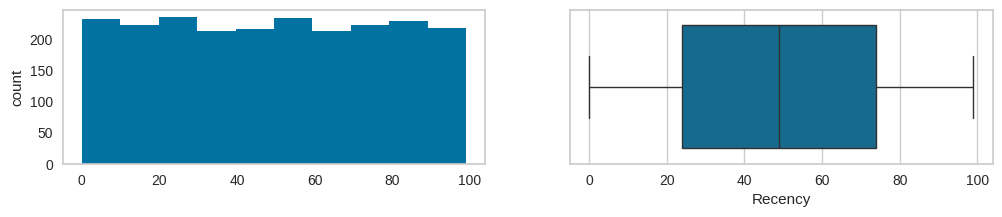

MntWines
Skew : 1.18


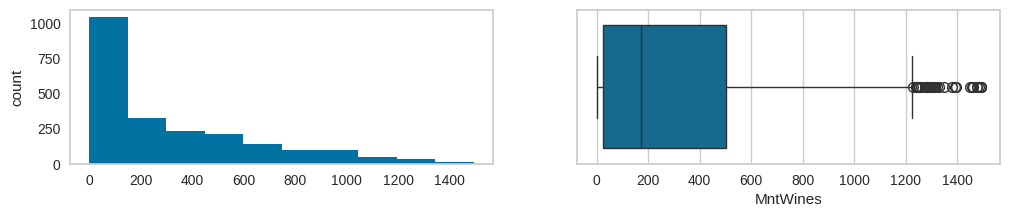

MntFruits
Skew : 2.1


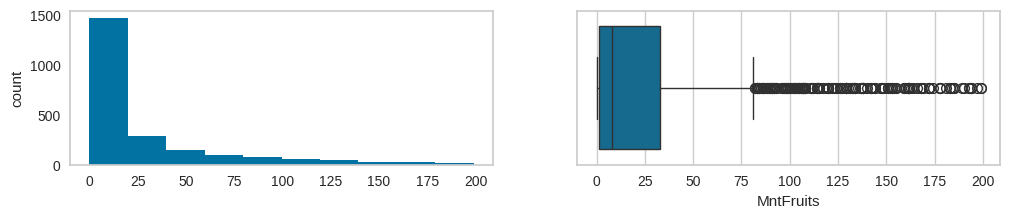

MntMeatProducts
Skew : 2.08


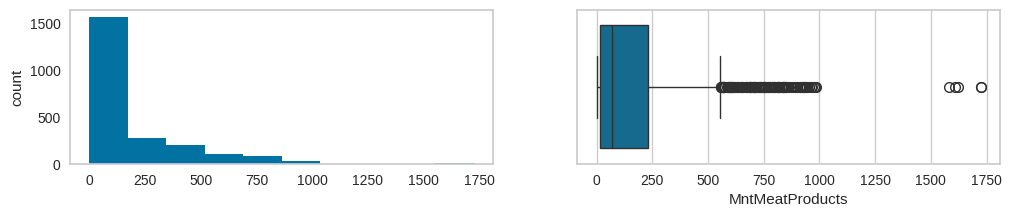

MntFishProducts
Skew : 1.92


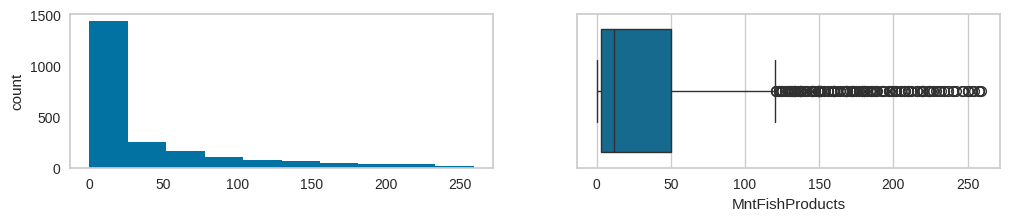

MntSweetProducts
Skew : 2.14


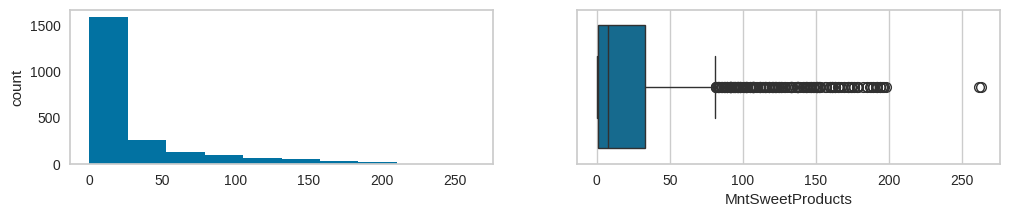

MntGoldProds
Skew : 1.89


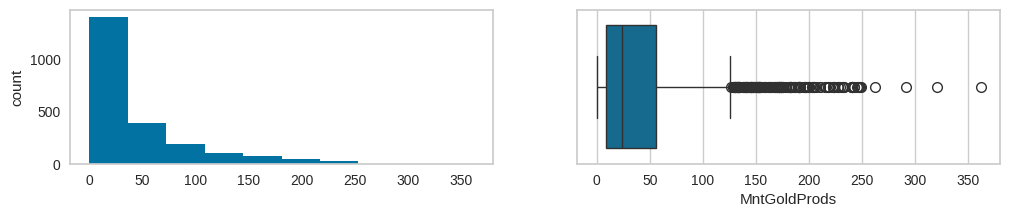

NumDealsPurchases
Skew : 2.42


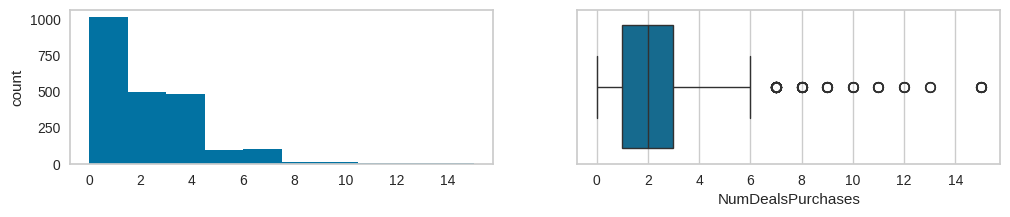

NumWebPurchases
Skew : 1.38


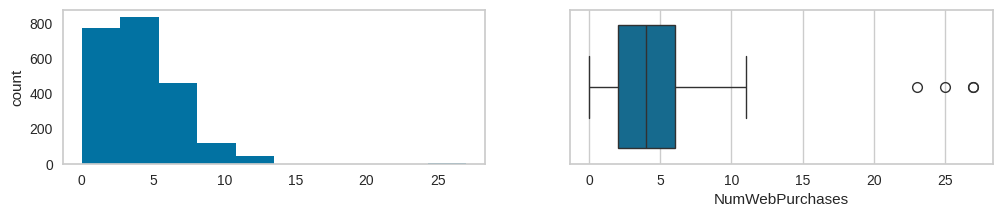

NumCatalogPurchases
Skew : 1.88


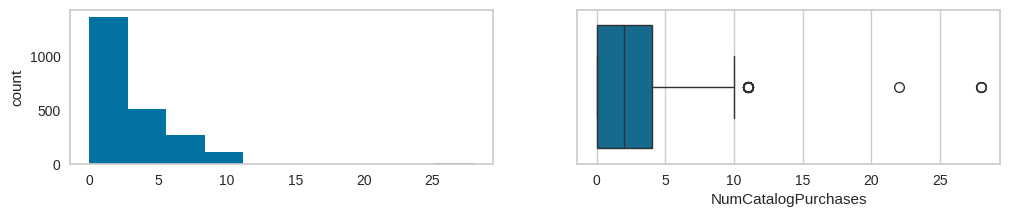

NumStorePurchases
Skew : 0.7


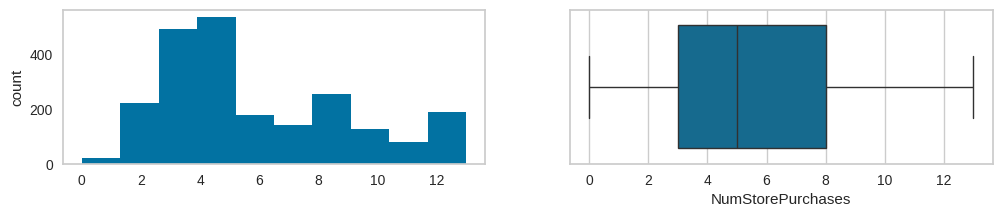

NumWebVisitsMonth
Skew : 0.21


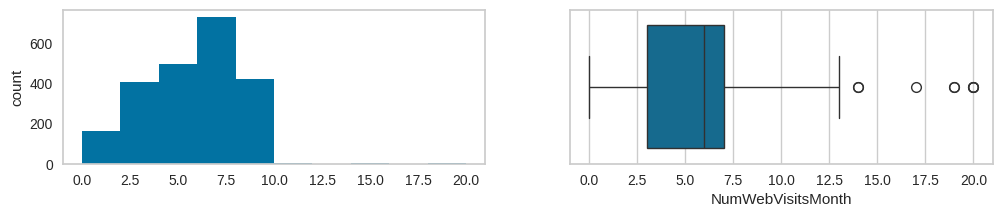

AcceptedCmp3
Skew : 3.29


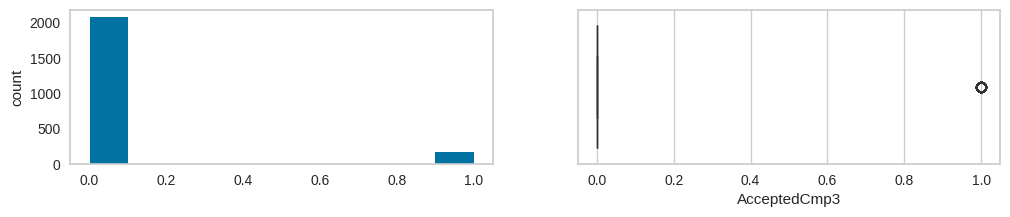

AcceptedCmp4
Skew : 3.24


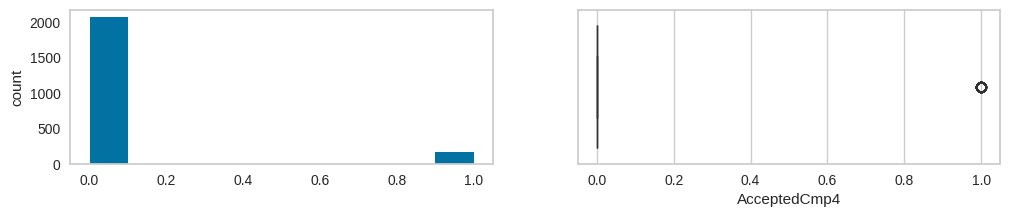

AcceptedCmp5
Skew : 3.29


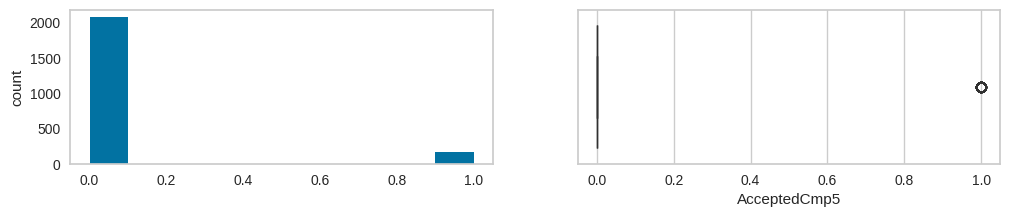

AcceptedCmp1
Skew : 3.56


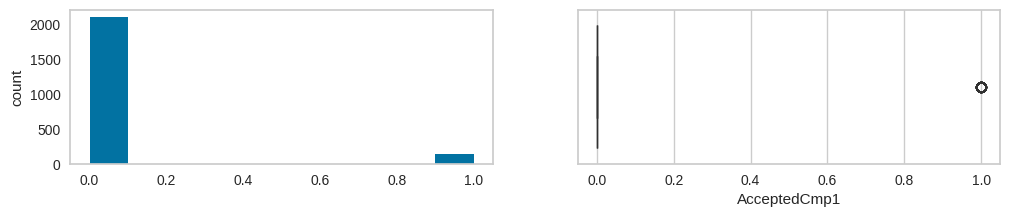

AcceptedCmp2
Skew : 8.47


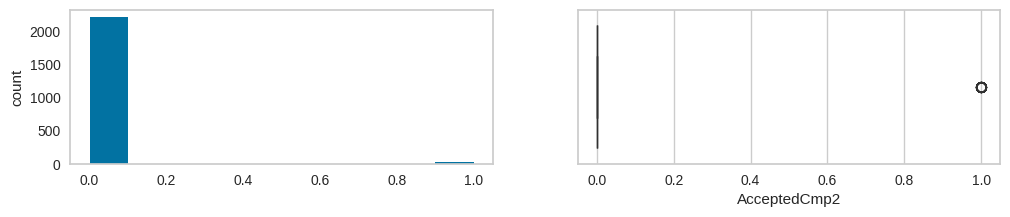

Complain
Skew : 10.19


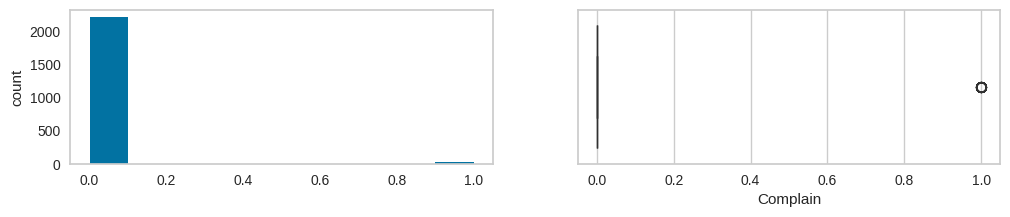

Z_CostContact
Skew : 0.0


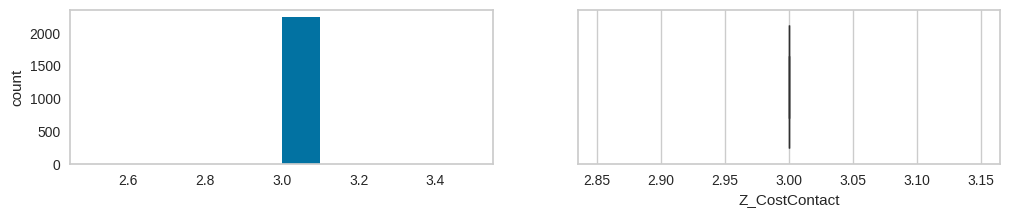

Z_Revenue
Skew : 0.0


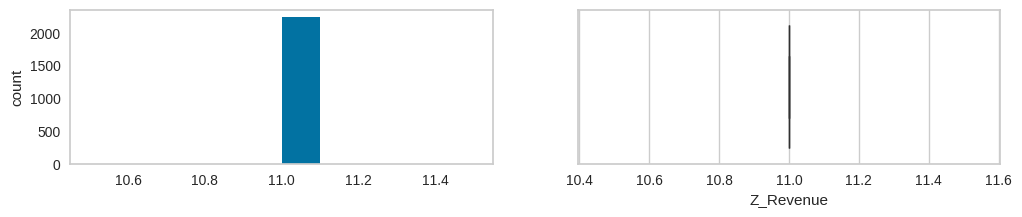

Response
Skew : 1.97


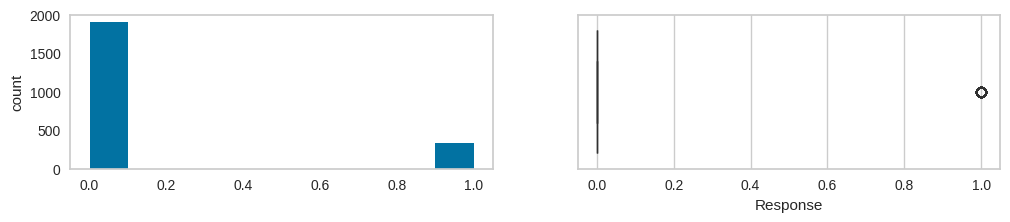

In [102]:
for col in num_data.columns:
    print(col)
    print('Skew :',round(num_data[col].skew(),2))
    plt.figure(figsize=(12,2))
    plt.subplot(1,2,1)
    data[col].hist(bins=10, grid=False)
    plt.ylabel('count')
    plt.subplot(1,2,2)
    sns.boxplot(x=data[col])
    plt.show()

### Bivariate Analysis

#### **Question 6:** Perform multivariate analysis to explore the relationsips between the variables.

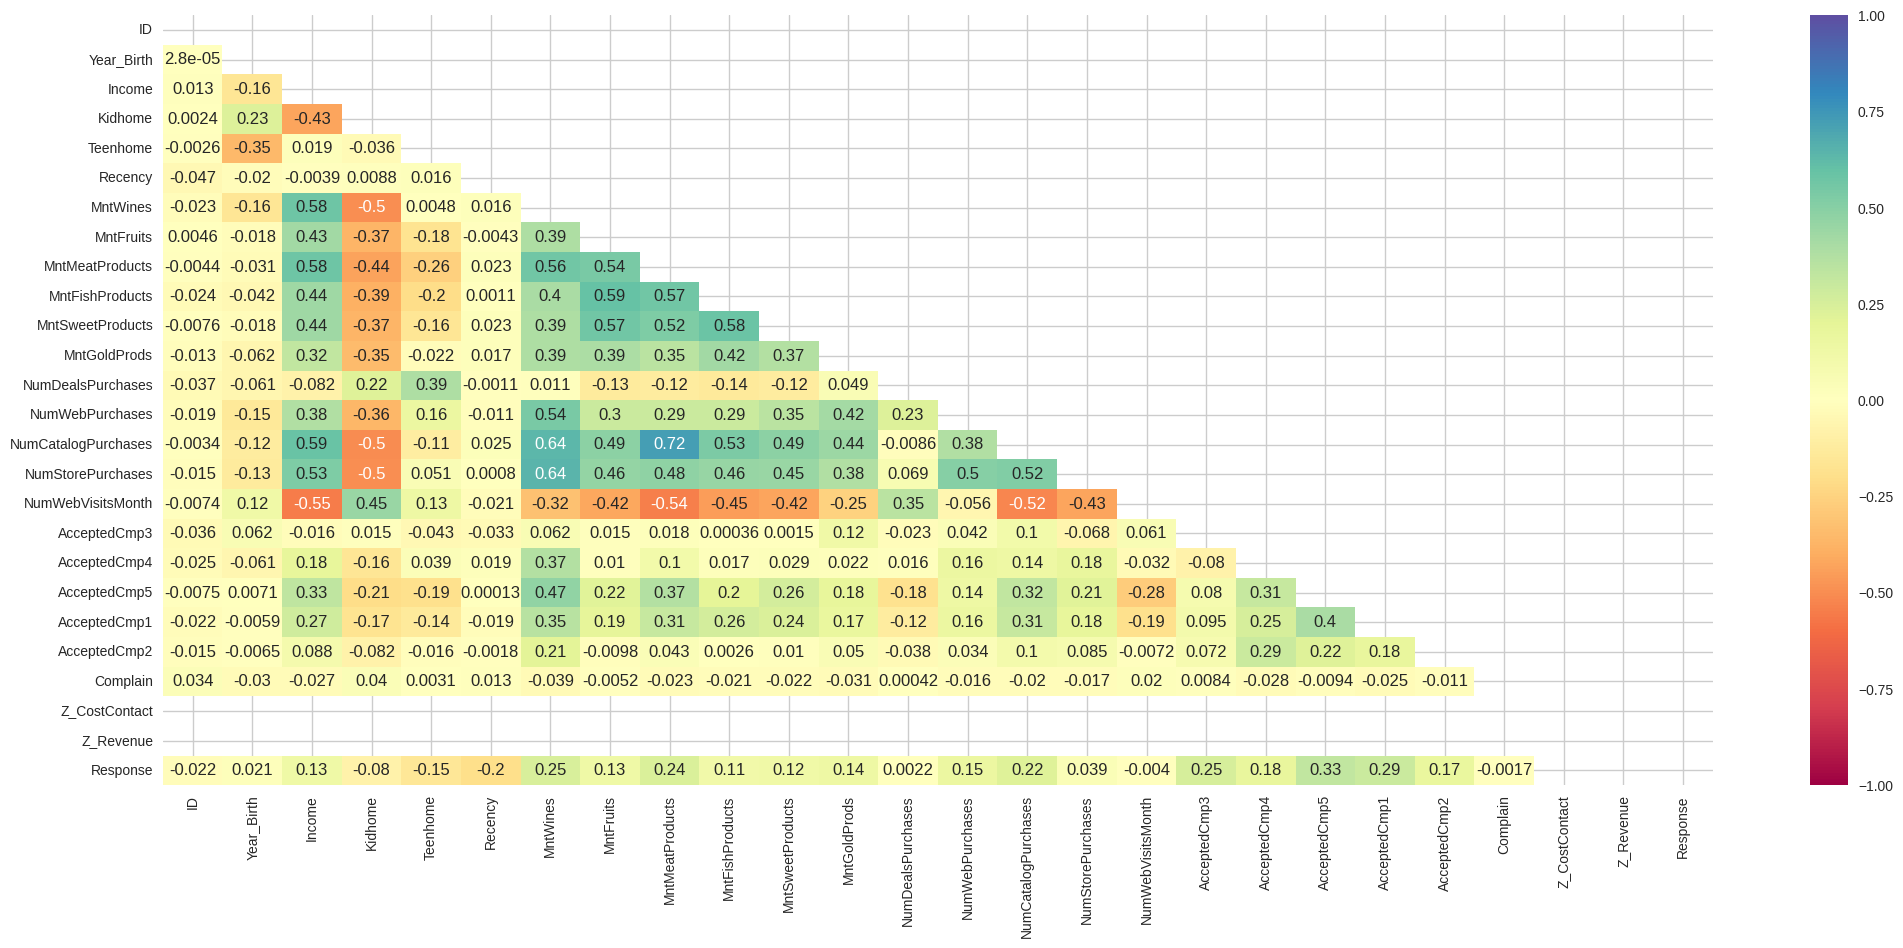

In [ ]:
plt.figure(figsize=(25,10))

corr = data.corr(numeric_only = True)

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True


sns.heatmap(corr, mask=mask, annot=True, cmap='Spectral', vmin=-1, vmax=1)
plt.show()

##### **Observations:**Positive correlation in Income across all products: Wines, Fruits, Fish and Meats signaling a customer base with more expendable income purchases more. Lower income signals more website traffic . There is a very strong positive correlation in Catalog purchases of Meat products.

The number of kids at home is negatively corelated with overall purchases. Although children at home correlate positively with Purchases made with coupons. Overall the number of Web Visits per Month seem to be decreasing overall across demographics and products, explaining the weak correlation between Web purchases generally. Catalog and In-Store purchases make a stronger and positive correlation across all product categories.



## **K-means Clustering**

#### **Question 7** : Select the appropriate number of clusters using the elbow Plot. What do you think is the appropriate number of clusters?

In [109]:
### A pre step before performing a K-Means algorithm is to scale the data.
### Only numerical data can be scaled; the scaler is applied to the dataframe created before for only numerical data.

scaler=StandardScaler()
scaledata=pd.DataFrame(scaler.fit_transform(num_data), columns=num_data.columns)
scaledata.head()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,-0.020999,-0.985345,0.235327,-0.825218,-0.929894,0.307039,0.983781,1.551577,1.679702,2.462147,1.476500,0.843207,0.349414,1.409304,2.510890,-0.550785,0.693904,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,2.388846
1,-1.053058,-1.235733,-0.235826,1.032559,0.906934,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,-0.729006,-0.168236,-1.110409,-0.568720,-1.166125,-0.130463,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,-0.418612
2,-0.447070,-0.317643,0.773633,-0.825218,-0.929894,-0.798086,0.362723,0.570804,-0.177032,1.345274,-0.146905,-0.038766,-0.685887,1.409304,-0.226541,1.295237,-0.542647,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,-0.418612
3,0.181716,1.268149,-1.022732,1.032559,-0.929894,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,-0.748179,-0.168236,-0.750450,-0.910898,-0.550785,0.281720,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,-0.418612
4,-0.082614,1.017761,0.241519,1.032559,-0.929894,1.550305,-0.389085,0.419916,-0.216914,0.155164,-0.001525,-0.556446,1.384715,0.329427,0.115638,0.064556,-0.130463,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,-0.418612


In [115]:
#creating a copy of the scaled data to work on
scaledata_copy = scaledata.copy(deep=True)

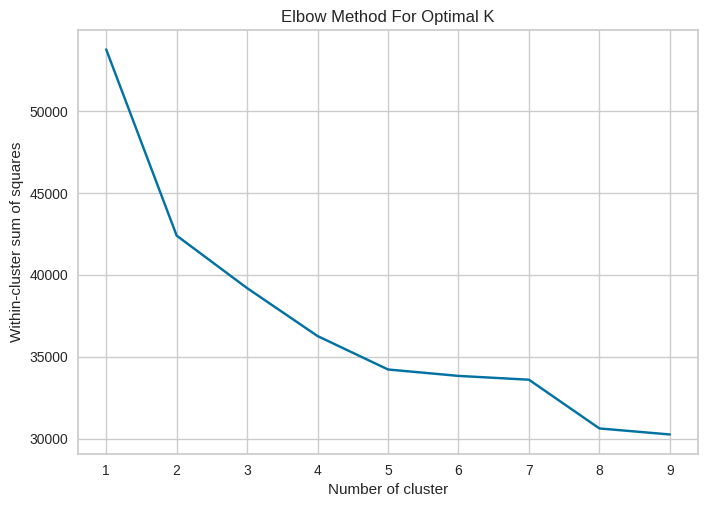

In [110]:
# step 1: initialize winthin-cluster sum of squares
wcss = {}

# step 2 - iterate for a range of Ks and fit the scaled data to the algorithm. Use inertia attribute from the clustering object and
# store the inertia value for that k
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(scaledata)
    wcss[k] = kmeans.inertia_

# step 3 plot the K clusters
plt.figure()
plt.plot(list(wcss.keys()), list(wcss.values()), 'bx-')
plt.xlabel("Number of cluster")
plt.ylabel("Within-cluster sum of squares")
plt.title("Elbow Method For Optimal K")
plt.show()

##### **Observations:**
The Within-Clusters Sum of Squares suggests that the steepest change in clusters occurs at K = 2 although it is unclear that this is best fit for the model as there is gradual decreases throughout the number of clusters. K=5 also provides a marker for possible well fit clustering.


***

#### **Question 8** : finalize appropriate number of clusters by checking the silhoutte score as well. Is the answer different from the elbow plot?

#### **Silhouette Score Analysis**

The Silhouette Score is another metric used to evaluate the quality of clusters created by clustering algorithms like K-Means. It quantifies how similar an object is to its own cluster compared to other clusters. The score ranges from -1 to 1, where:

*   **1** indicates that the object is well-matched to its own cluster and poorly matched to neighboring clusters.
*   **0** indicates that the object is on or very close to the decision boundary between two neighboring clusters.
*   **-1** indicates that the object is probably assigned to the wrong cluster.

For K = 2, Silhouette Score = 0.253
For K = 3, Silhouette Score = 0.224
For K = 4, Silhouette Score = 0.18
For K = 5, Silhouette Score = 0.105
For K = 6, Silhouette Score = 0.092
For K = 7, Silhouette Score = 0.099
For K = 8, Silhouette Score = 0.105
For K = 9, Silhouette Score = 0.113


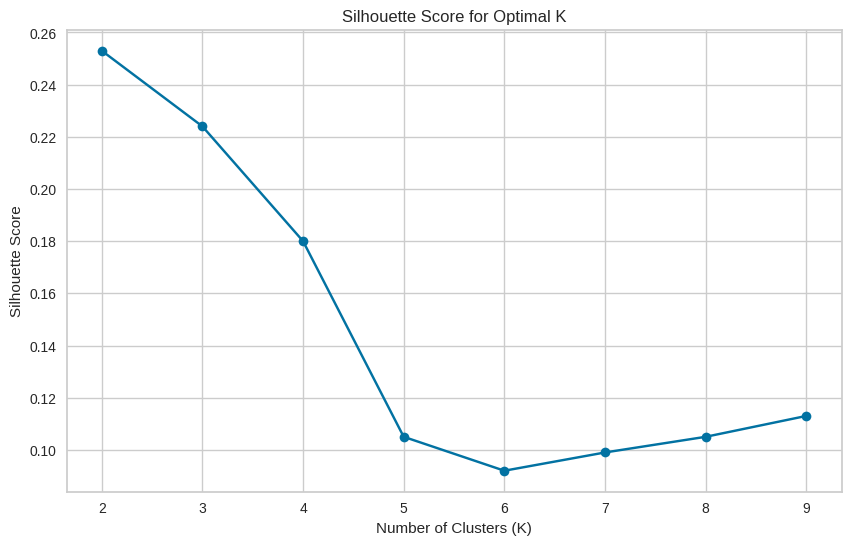

In [111]:
#code rpovided by Gemini

# A list to store silhouette scores for different K values
silhouette_scores = []

# Iterate for a range of Ks (starting from 2, as silhouette score requires at least 2 clusters)
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto').fit(scaledata)
    score = silhouette_score(scaledata, kmeans.labels_)
    sil_score_round = round(score, 3)
    silhouette_scores.append(sil_score_round)
    print(f'For K = {k}, Silhouette Score = {sil_score_round}')

# Plot the silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, 10), silhouette_scores, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal K')
plt.grid(True)
plt.show()

##### **Observations:**
After applying the silhouette method, K=2 shows the 'hieghest/ closest to 1' score for clustering measuring .253.

.253 is a fairly weak silhouette score, however it provides the strongest indicator of a best K for this data.  

After both methods are applied there is strong evidence that K=2 clusters is the optimal number of clusters to apply K-Means algorithm.




##### **Observations:**

#### **Question 9**: Do a final fit with the appropriate number of clusters. How much total time does it take for the model to fit the data?

In [121]:
kmean = KMeans(n_clusters=2, max_iter= 1200, random_state=42, n_init='auto')
kmean.fit(scaledata)

scaledata_copy['Labels'] = kmean.predict(scaledata)
data['Labels'] = kmean.predict(scaledata)

In [124]:
#Calculating summary statistics of the original data for each label
mean = scaledata_copy.groupby('Labels').mean()
median = scaledata_copy.groupby('Labels').median()
df_kmeans = pd.concat([mean, median], axis=0)
df_kmeans.index = ['group_0 Mean', 'group_1 Mean', 'group_0 Median', 'group_1 Median']
df_kmeans.T

,group_0 Mean,group_1 Mean,group_0 Median,group_1 Median
ID,-0.006673,0.010333,-0.046569,-0.020999
Year_Birth,0.093845,-0.145305,0.183134,-0.150717
Income,-0.516499,0.799721,-0.544389,0.773633
Kidhome,0.453795,-0.702634,1.032559,-0.825218
Teenhome,0.098514,-0.152534,0.906934,-0.929894
Recency,-0.008472,0.013117,-0.003777,0.065293
MntWines,-0.583008,0.902700,-0.799162,0.766857
MntFruits,-0.490291,0.759142,-0.586005,0.394768
MntMeatProducts,-0.570719,0.883673,-0.646755,0.611748
MntFishProducts,-0.505118,0.782099,-0.613830,0.484733


##### **Observations:**

## **Cluster Profiling and Comparison**

#### **Question 10**: Perform cluster profiling using boxplots for the K-Means algorithm. Analyze key characteristics of each cluster and provide detailed observations.

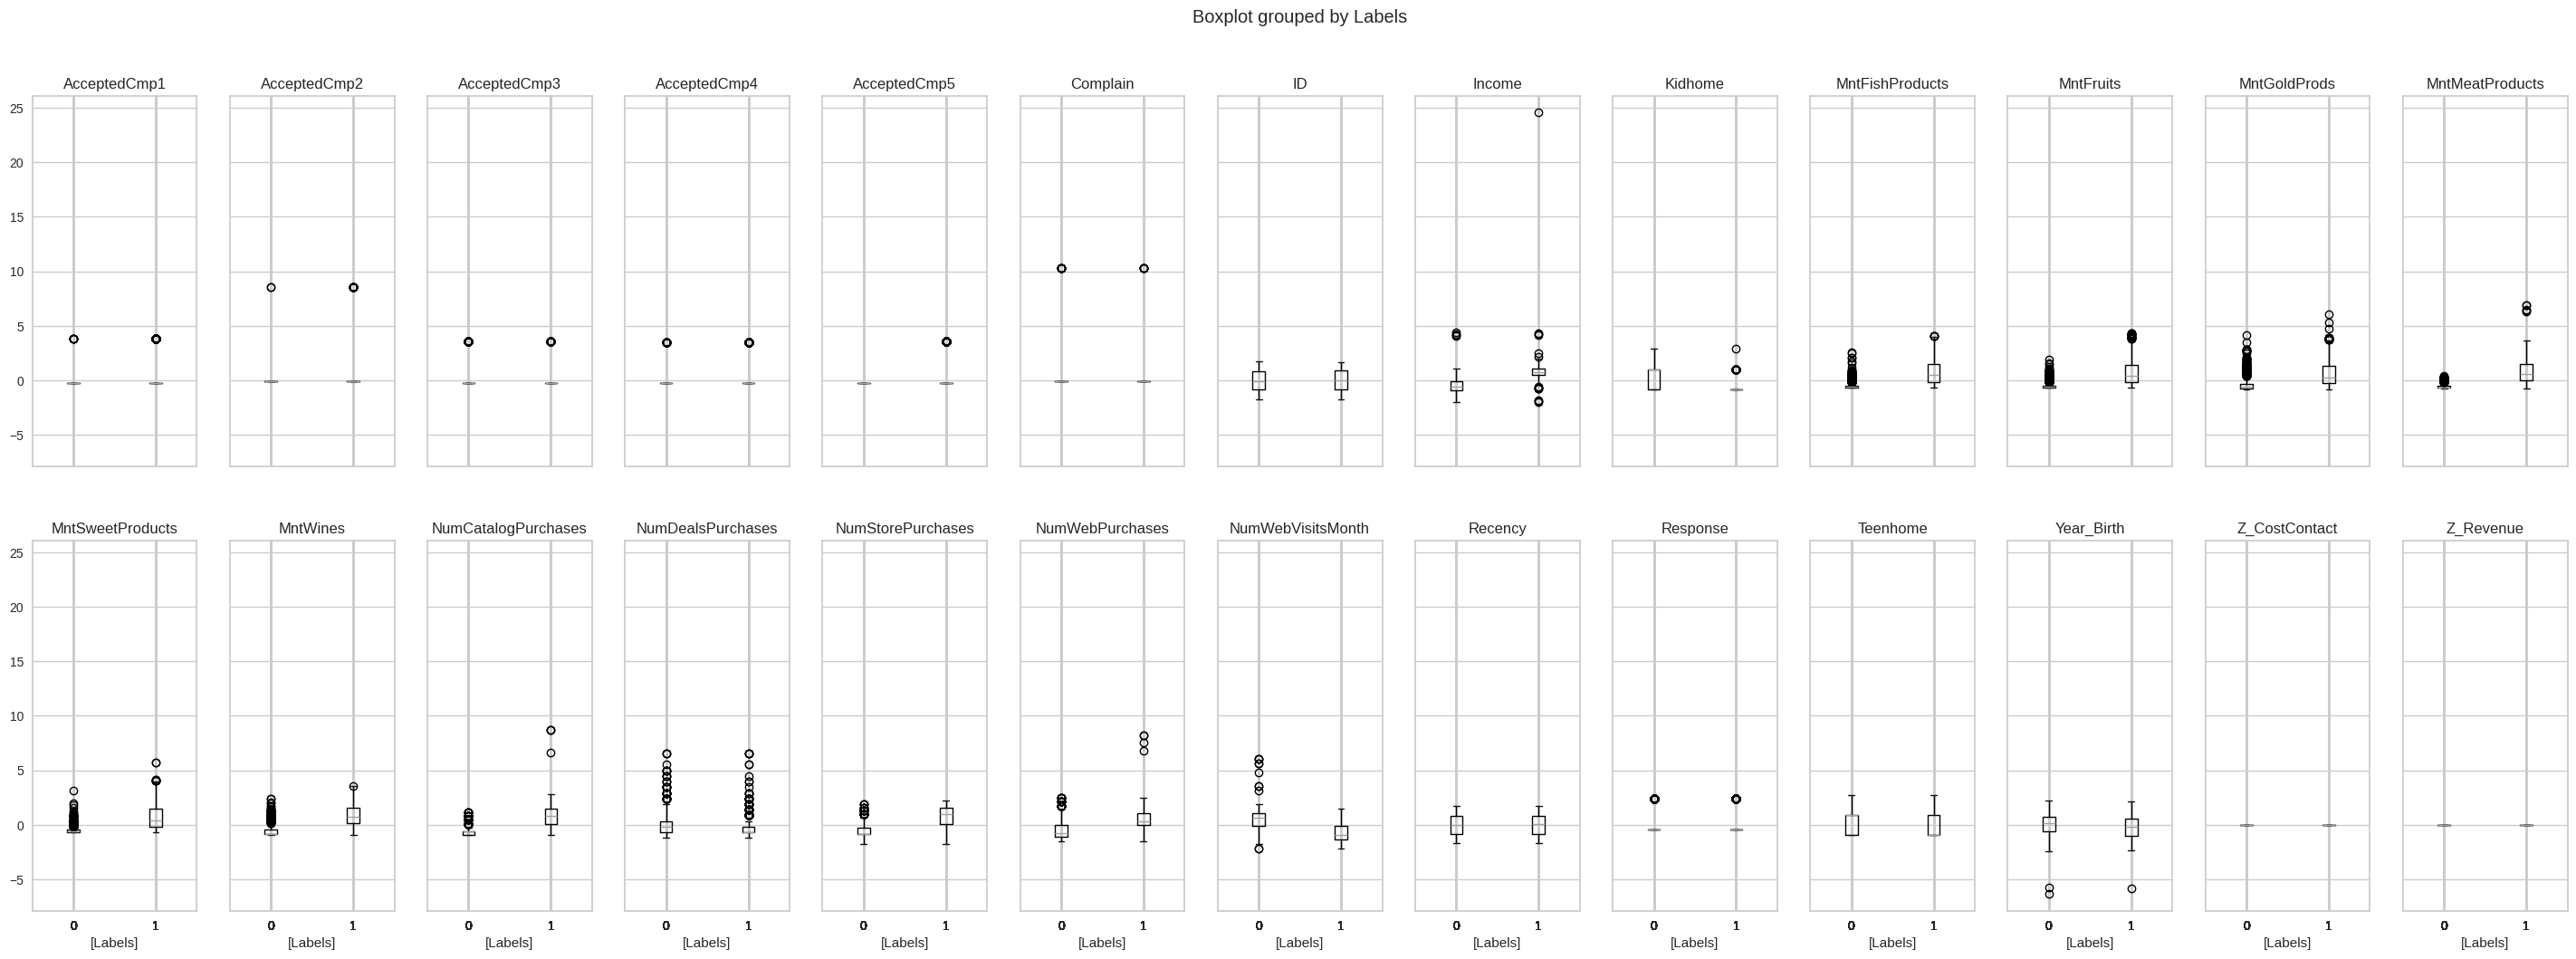

In [132]:
scaledata_copy.boxplot(by = 'Labels', layout = (2,13),figsize=(35,12))
plt.show()

In [ ]:
# Write your code here

##### **Observations:**

The data is not well displayed in barplot. Some obervatiosn can be made:

After applying the Kmean Algorithm the most notable observation is that households with kids and teens at home are purchasing with deals more often. The Accepted rate of Campaigns seems unchanged throughout their iterations. People without kids/ teens seem to be the biggest demographic buying a wide variety of products in more frequency.

#### **Question 11**: Perform cluster profiling on the data using a barplot for the K-Means algorithm. Provide insights and key observations for each cluster based on the visual analysis.

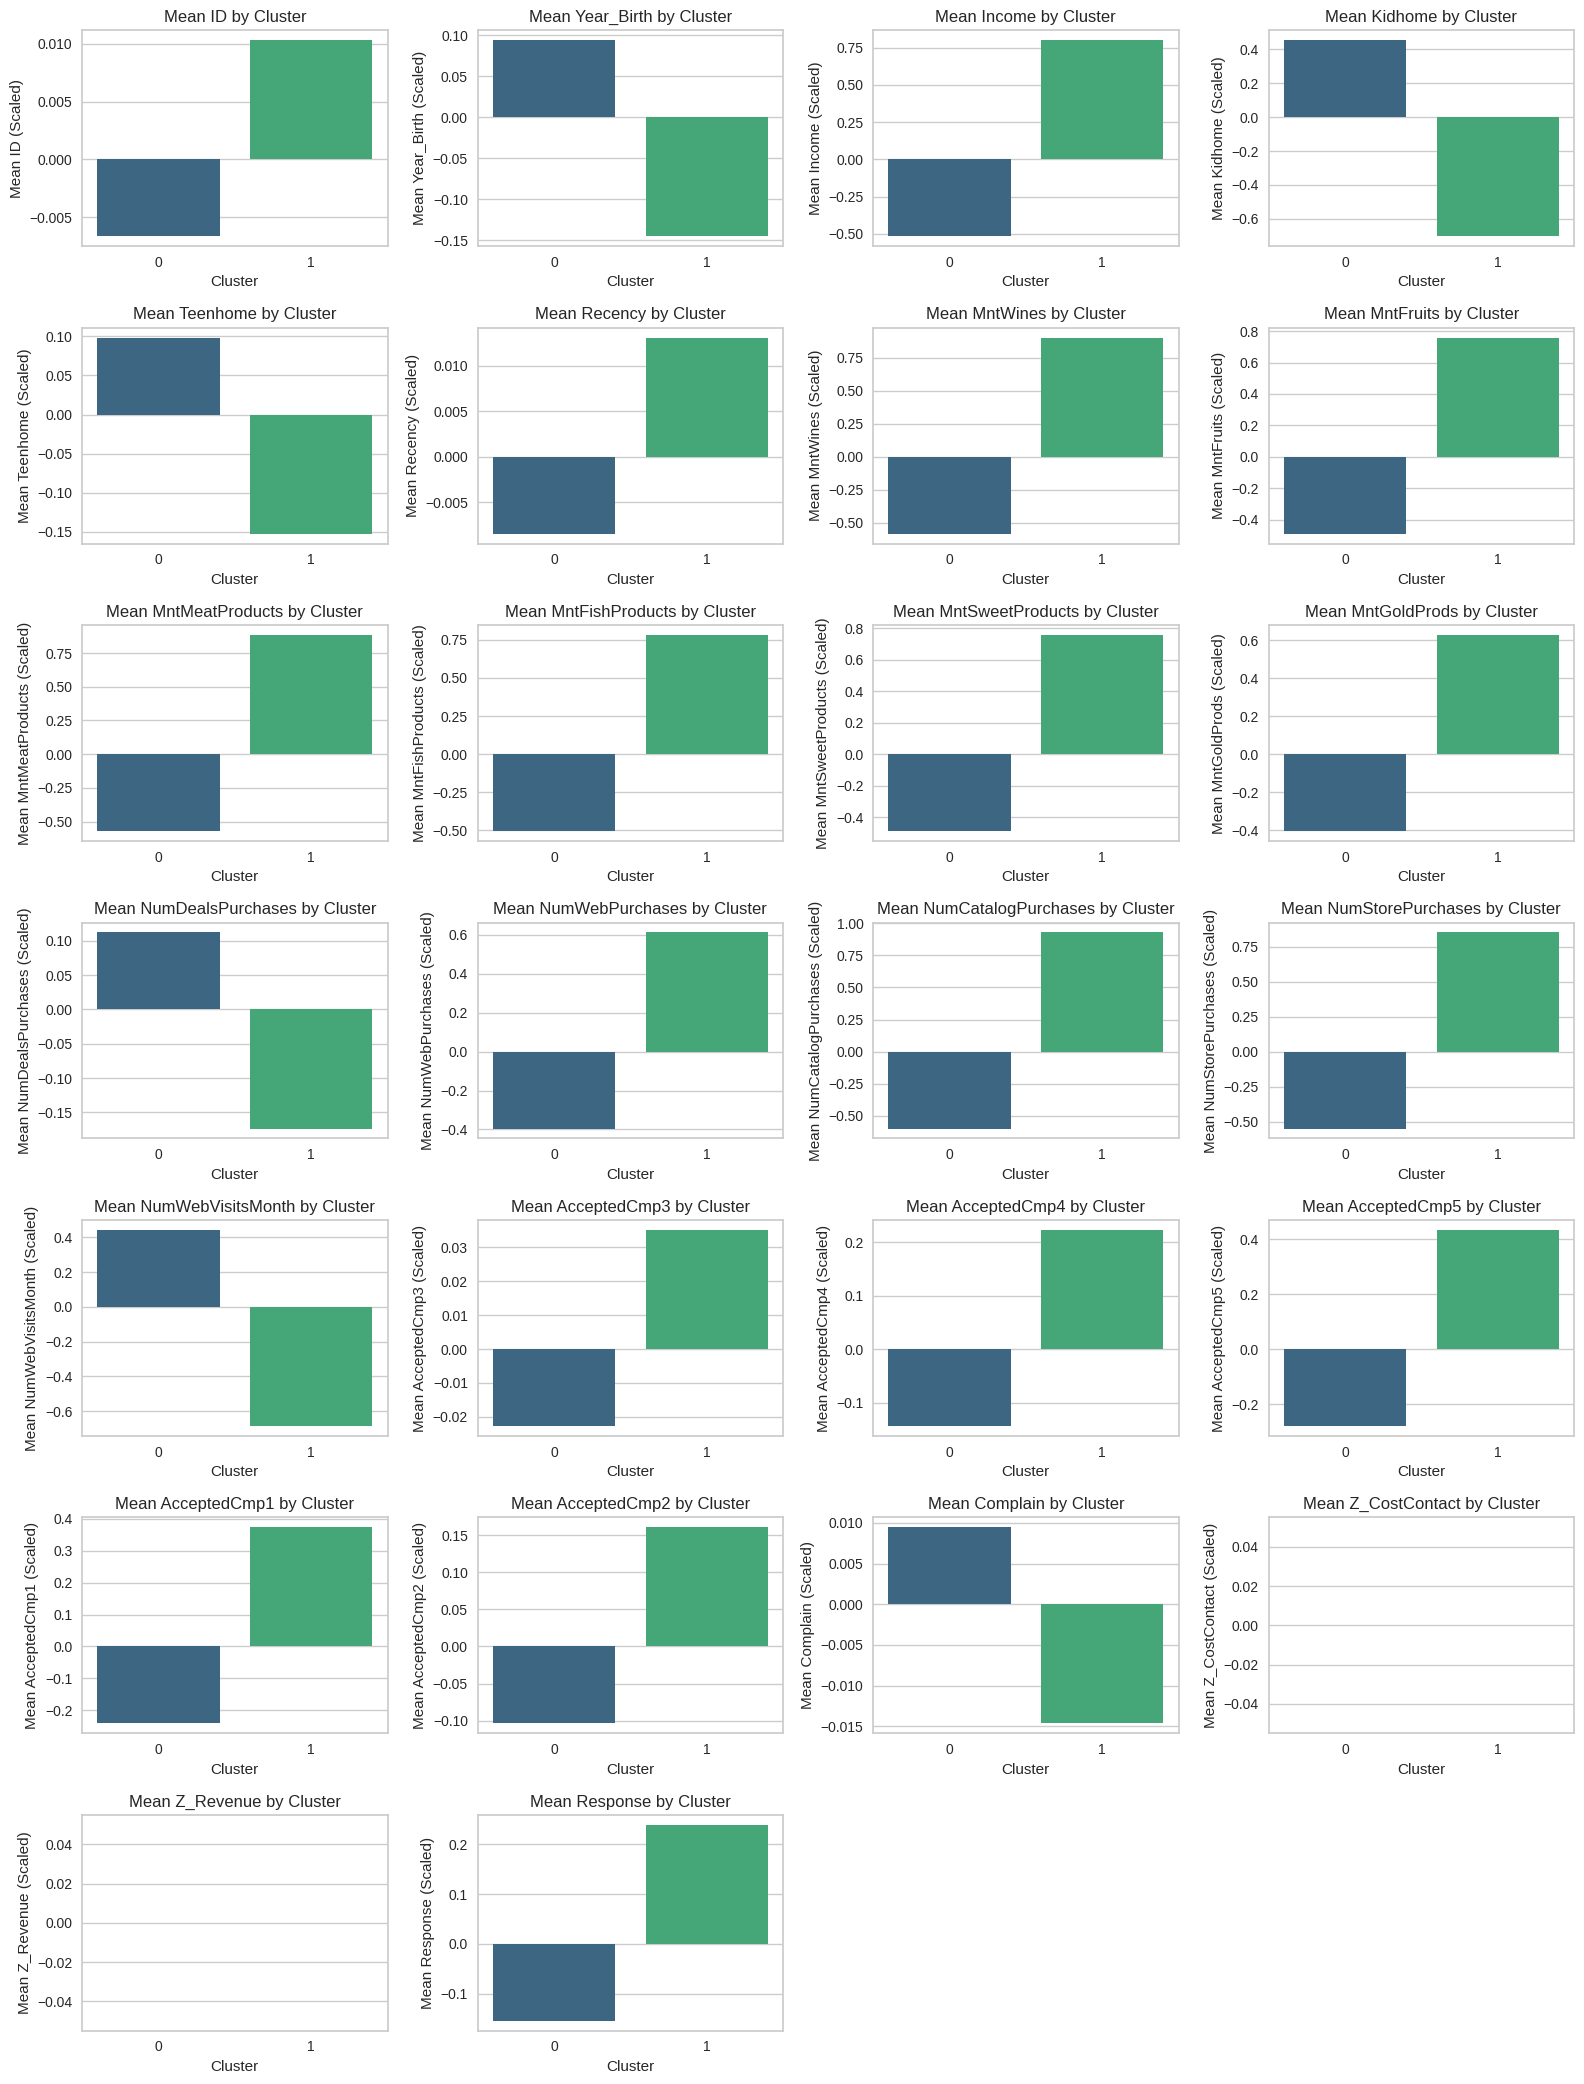

In [135]:
###code provided by Gemini

# Get the mean values for each cluster from the 'mean' DataFrame
# 'mean' DataFrame has 'Labels' as index (0, 1) and features as columns.
mean_df = mean.reset_index() # To make 'Labels' a column for seaborn

num_features = len(mean_df.columns) - 1 # Exclude 'Labels' column
n_cols = 4
n_rows = (num_features + n_cols - 1) // n_cols # Calculate rows needed

plt.figure(figsize=(n_cols * 4, n_rows * 3)) # Adjust overall figure size

for i, col in enumerate(mean_df.columns[1:]): # Iterate over feature columns (excluding 'Labels')
    plt.subplot(n_rows, n_cols, i + 1)
    sns.barplot(x='Labels', y=col, data=mean_df, palette='viridis')
    plt.title(f'Mean {col} by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(f'Mean {col} (Scaled)')

plt.tight_layout()
plt.show()

##### **Observations:** Many of the same observations can be made clearer displaying the two groups in barcharts.

## **Business Recommedations**

#### **Question 12**: Based on the cluster insights, what business recommendations can be provided?


Online ad campaigns could be targeted towards families which have a higher number of website visits per month and purchases made with Coupons.
Perhaps a good business development idea is to provide more coupon deals towards families in a variety of products to increase traffic, a more sales towards this demographic.
 Households without children at home seem to have higher incomes and possibly with more disposable income, this group Accepts Campaign Offers more often. Focusing Campaigns on this group should increase the campaign numbers.
 Targeting the right deals, campaigns to these demographics could improve sales, customer retention and create new business and growth.
